In [1]:
import pandas as pd

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [3]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

np.int64(0)

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

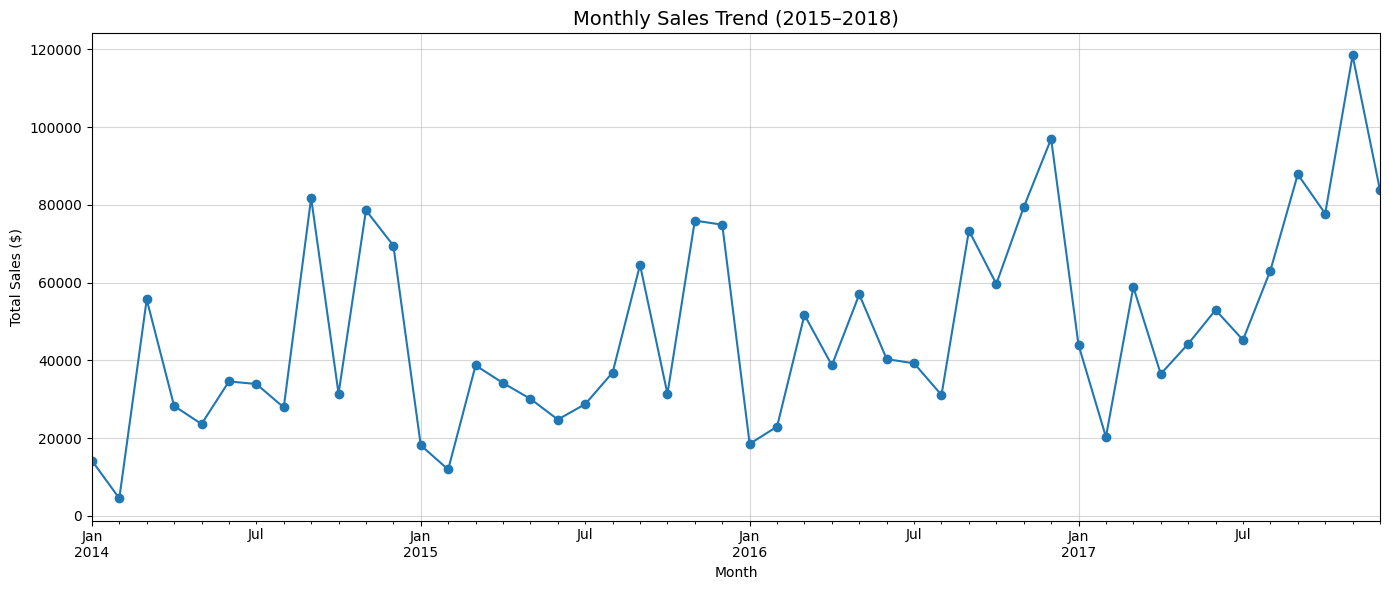

In [7]:
import matplotlib.pyplot as plt


monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()


plt.figure(figsize=(14, 6))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend (2015–2018)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=150)

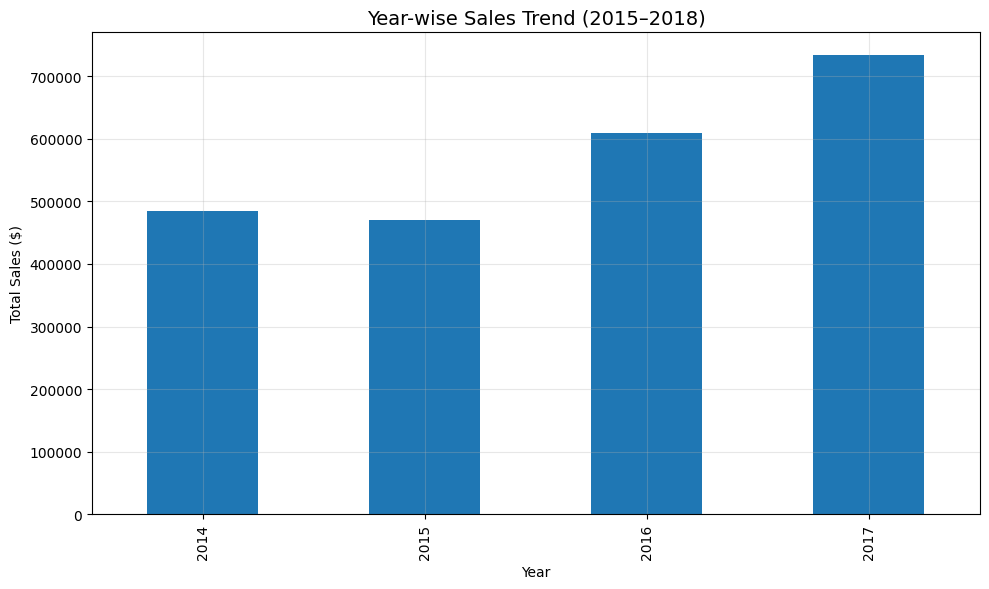

In [8]:
import matplotlib.pyplot as plt


yearly_sales = df.groupby(df['Order Date'].dt.year)['Sales'].sum()

plt.figure(figsize=(10, 6))
yearly_sales.plot(kind='bar')

plt.title('Year-wise Sales Trend (2015–2018)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('yearly_sales_trend.png', dpi=150)
plt.show()


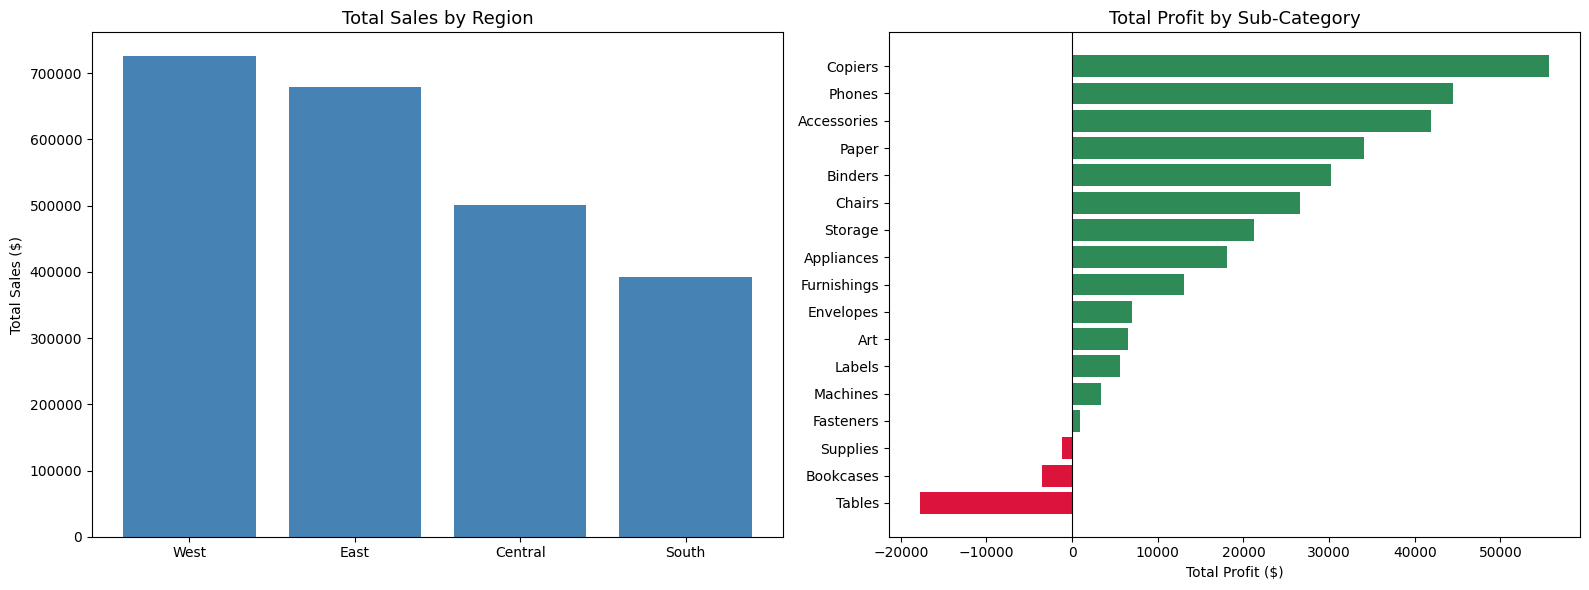

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[0].bar(region_sales.index, region_sales.values, color='steelblue')
axes[0].set_title('Total Sales by Region', fontsize=13)
axes[0].set_ylabel('Total Sales ($)')


subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['crimson' if x < 0 else 'seagreen' for x in subcat_profit.values]
axes[1].barh(subcat_profit.index, subcat_profit.values, color=colors)
axes[1].set_title('Total Profit by Sub-Category', fontsize=13)
axes[1].set_xlabel('Total Profit ($)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('category_region_performance.png', dpi=150)
plt.show()

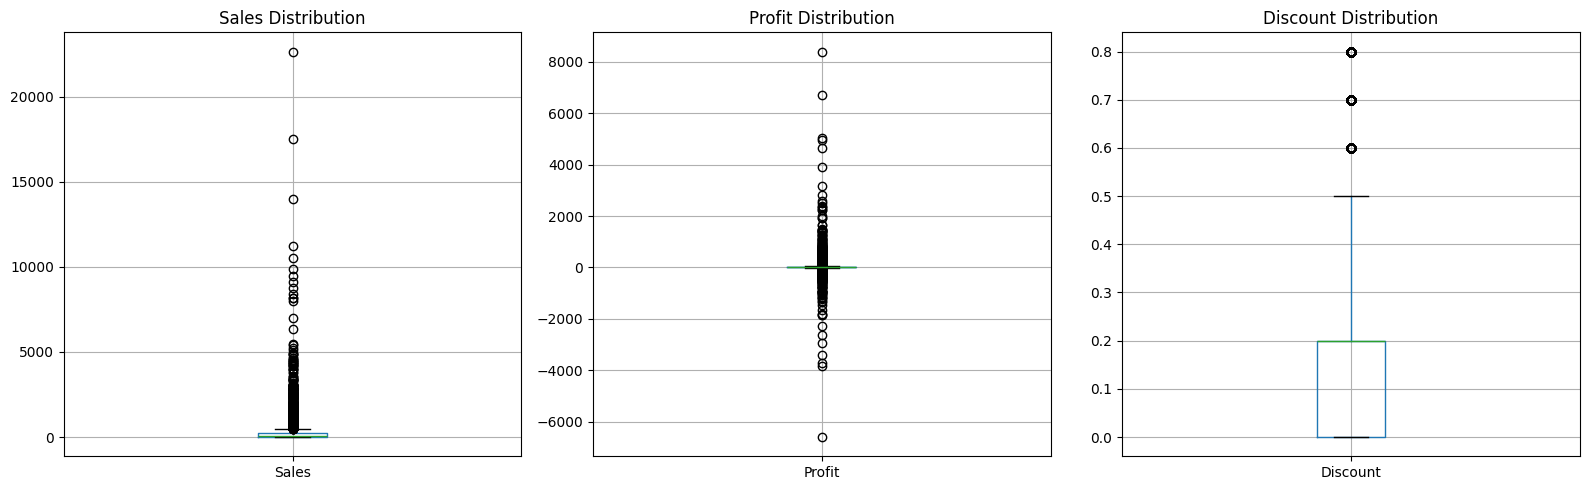

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df.boxplot(column='Sales', ax=axes[0])
axes[0].set_title('Sales Distribution')

df.boxplot(column='Profit', ax=axes[1])
axes[1].set_title('Profit Distribution')

df.boxplot(column='Discount', ax=axes[2])
axes[2].set_title('Discount Distribution')

plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=150)
plt.show()

In [11]:
high_discount = df[df['Discount'] >= 0.5]
print(high_discount['Category'].value_counts())
print("\n")
print(high_discount['Sub-Category'].value_counts())

Category
Office Supplies    680
Furniture          207
Technology          35
Name: count, dtype: int64


Sub-Category
Binders        613
Furnishings    138
Appliances      67
Tables          36
Machines        35
Bookcases       33
Name: count, dtype: int64


In [12]:
loss_makers = df[df['Sub-Category'].isin(['Tables', 'Bookcases'])]

summary = loss_makers.groupby('Sub-Category').agg(
    Avg_Discount=('Discount', 'mean'),
    Avg_Profit_Margin=('Profit', lambda x: x.sum() / loss_makers.loc[x.index, 'Sales'].sum() * 100),
    Total_Orders=('Order ID', 'count'),
    Orders_With_Discount=('Discount', lambda x: (x > 0).sum())
).round(2)

print(summary)

              Avg_Discount  Avg_Profit_Margin  Total_Orders  \
Sub-Category                                                  
Bookcases             0.21              -3.02           228   
Tables                0.26              -8.56           319   

              Orders_With_Discount  
Sub-Category                        
Bookcases                      168  
Tables                         247  


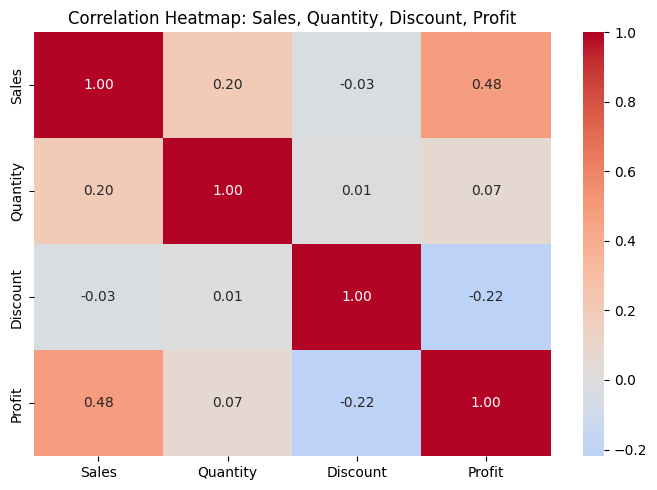

In [13]:
import seaborn as sns

corr_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap: Sales, Quantity, Discount, Profit')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [14]:
from google.colab import files
files.download('monthly_sales_trend.png')
files.download('category_region_performance.png')
files.download('outlier_detection.png')
files.download('correlation_heatmap.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales = daily_sales.rename(columns={'Order Date': 'Date'})
date_range = pd.date_range(start=daily_sales['Date'].min(), end=daily_sales['Date'].max(), freq='D')
daily_sales = daily_sales.set_index('Date').reindex(date_range, fill_value=0).reset_index()
daily_sales = daily_sales.rename(columns={'index': 'Date'})
print(f"Total days: {len(daily_sales)}")
print(f"Date range: {daily_sales['Date'].min()} to {daily_sales['Date'].max()}")
daily_sales.head()

Total days: 1458
Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00


,Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [16]:

split_date = daily_sales['Date'].max() - pd.Timedelta(days=90)

train = daily_sales[daily_sales['Date'] <= split_date]
test = daily_sales[daily_sales['Date'] > split_date]

print(f"Train period: {train['Date'].min()} to {train['Date'].max()} ({len(train)} days)")
print(f"Test period: {test['Date'].min()} to {test['Date'].max()} ({len(test)} days)")

Train period: 2014-01-03 00:00:00 to 2017-10-01 00:00:00 (1368 days)
Test period: 2017-10-02 00:00:00 to 2017-12-30 00:00:00 (90 days)


In [17]:
last_7day_avg = train['Sales'].tail(7).mean()
print(f"Baseline prediction (flat): ${last_7day_avg:.2f} per day")

test = test.copy()
test['Baseline_Pred'] = last_7day_avg

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_baseline = np.sqrt(mean_squared_error(test['Sales'], test['Baseline_Pred']))
mae_baseline = mean_absolute_error(test['Sales'], test['Baseline_Pred'])

print(f"Baseline RMSE: ${rmse_baseline:.2f}")
print(f"Baseline MAE: ${mae_baseline:.2f}")

Baseline prediction (flat): $1274.48 per day
Baseline RMSE: $3504.16
Baseline MAE: $2363.99


In [18]:
!pip install -q pmdarima

from pmdarima import auto_arima

model_arima = auto_arima(
    train['Sales'],
    seasonal=True,
    m=7,
    stepwise=True,
    suppress_warnings=True,
    trace=True
)

print(model_arima.summary())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 7.7 MB/s eta 0:00:00
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=6.97 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=25631.605, Time=0.09 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=25240.731, Time=0.40 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=24775.420, Time=2.44 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=25629.606, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=24793.686, Time=0.80 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=6.42 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=24773.030, Time=6.28 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=9.21 sec
 ARIMA(0,1,0)(0,0,2)[7] intercept   : AIC=25622.386, Time=0.57 sec
 ARIMA(1,1,1)(0,0,2)[7] intercept   : AIC=24797.263, Time=3.31 sec
 ARIMA(0,1,2)(0,0,2)[7] intercept   : AIC=24782.961, Time=5.03 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=25240.842, Time=1.80 sec
 ARIMA(1,1,2)(0,0,2)[7] 

In [19]:

n_periods = len(test)
arima_forecast = model_arima.predict(n_periods=n_periods)

test = test.copy()
test['ARIMA_Pred'] = arima_forecast.values


rmse_arima = np.sqrt(mean_squared_error(test['Sales'], test['ARIMA_Pred']))
mae_arima = mean_absolute_error(test['Sales'], test['ARIMA_Pred'])

print(f"ARIMA RMSE: ${rmse_arima:.2f}")
print(f"ARIMA MAE: ${mae_arima:.2f}")


print(f"\nBaseline RMSE: ${rmse_baseline:.2f} | ARIMA RMSE: ${rmse_arima:.2f}")
print(f"Baseline MAE: ${mae_baseline:.2f} | ARIMA MAE: ${mae_arima:.2f}")

ARIMA RMSE: $3083.23
ARIMA MAE: $2215.05

Baseline RMSE: $3504.16 | ARIMA RMSE: $3083.23
Baseline MAE: $2363.99 | ARIMA MAE: $2215.05


In [20]:

!pip install -q prophet

from prophet import Prophet

# Prophet requires specific column names: 'ds' for date, 'y' for value
prophet_train = train.rename(columns={'Date': 'ds', 'Sales': 'y'})

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
model_prophet.fit(prophet_train)

# Create future dataframe matching our test period and forecast
future = model_prophet.make_future_dataframe(periods=len(test))
forecast = model_prophet.predict(future)

# Extract just the test period predictions
prophet_pred = forecast[['ds', 'yhat']].tail(len(test))
test['Prophet_Pred'] = prophet_pred['yhat'].values

# Evaluate
rmse_prophet = np.sqrt(mean_squared_error(test['Sales'], test['Prophet_Pred']))
mae_prophet = mean_absolute_error(test['Sales'], test['Prophet_Pred'])

print(f"Prophet RMSE: ${rmse_prophet:.2f}")
print(f"Prophet MAE: ${mae_prophet:.2f}")

Prophet RMSE: $2869.22
Prophet MAE: $2025.99


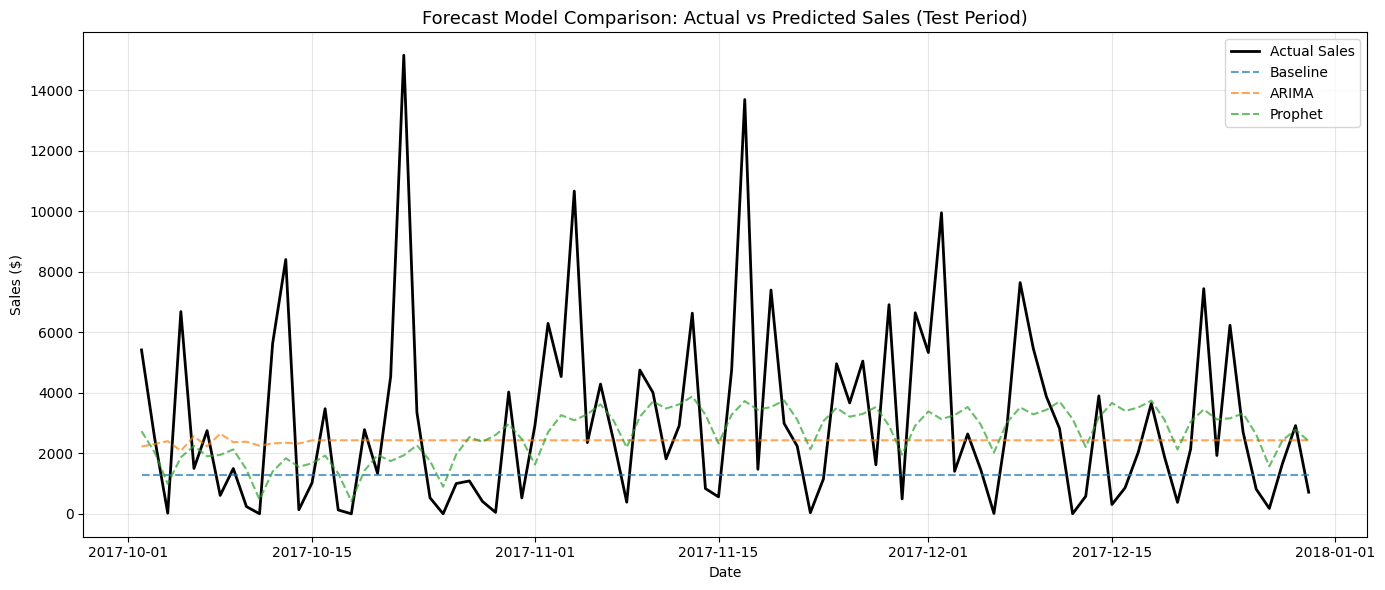

In [21]:
plt.figure(figsize=(14, 6))
plt.plot(test['Date'], test['Sales'], label='Actual Sales', color='black', linewidth=2)
plt.plot(test['Date'], test['Baseline_Pred'], label='Baseline', linestyle='--', alpha=0.7)
plt.plot(test['Date'], test['ARIMA_Pred'], label='ARIMA', linestyle='--', alpha=0.7)
plt.plot(test['Date'], test['Prophet_Pred'], label='Prophet', linestyle='--', alpha=0.7)
plt.title('Forecast Model Comparison: Actual vs Predicted Sales (Test Period)', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150)
plt.show()

In [24]:

snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,AA-10315,185,5,5563.560
1,AA-10375,20,9,1056.390
2,AA-10480,260,4,1790.512
3,AA-10645,56,6,5086.935
4,AB-10015,416,3,886.156


In [30]:
from sklearn.preprocessing import StandardScaler

features = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print(scaled_features[:5])  # peek at first 5 rows after scaling

[[ 0.19988856 -0.51642886  1.01511197]
 [-0.68676201  1.05264427 -0.70059002]
 [ 0.60291154 -0.90869715 -0.4211387 ]
 [-0.49331098 -0.12416058  0.83367962]
 [ 1.44119935 -1.30096543 -0.76539139]]


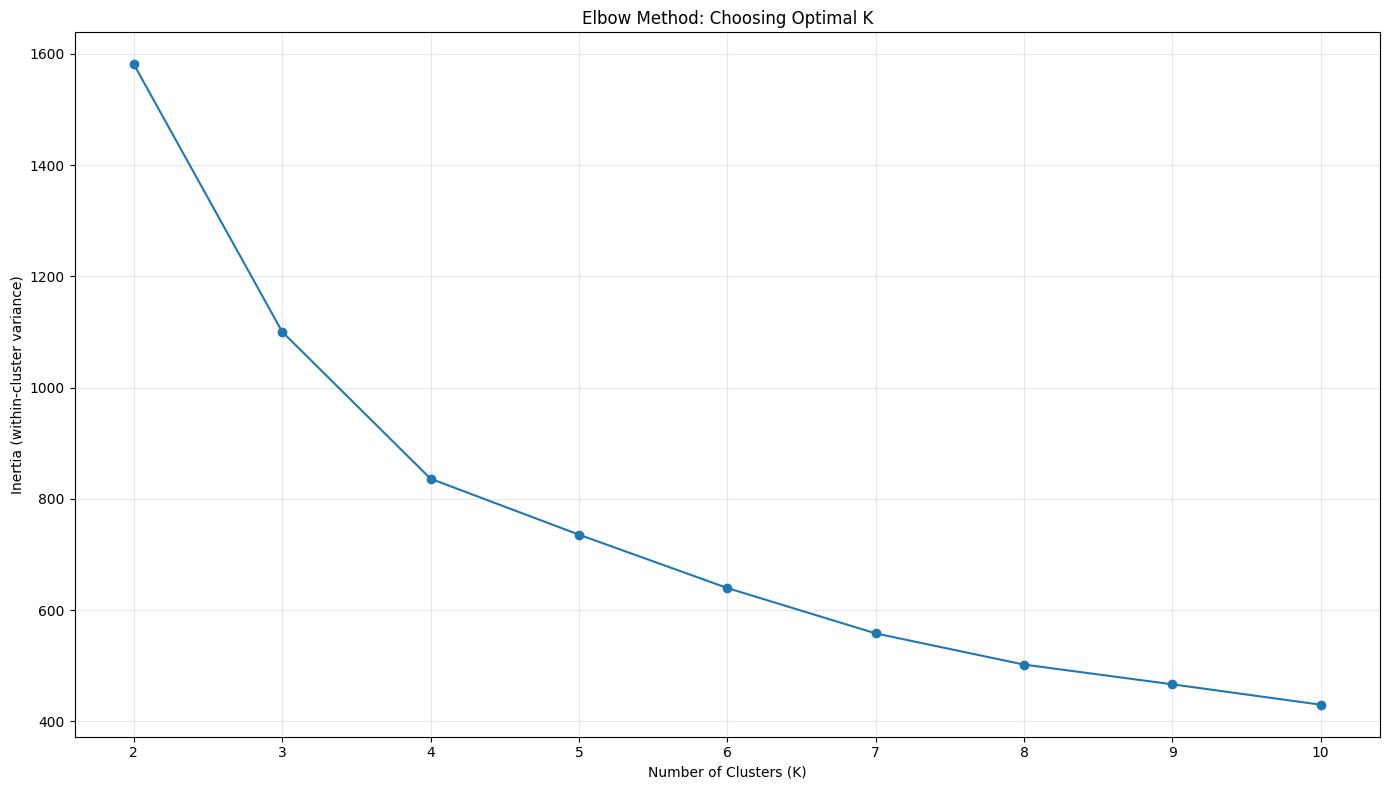

In [33]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(14, 8))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method: Choosing Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (within-cluster variance)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150)
plt.show()

In [34]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(scaled_features)

# Summarize each cluster's characteristics
cluster_summary = rfm.groupby('Cluster').agg(
    Num_Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(1)

print(cluster_summary)

         Num_Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                         
0                  298         72.7            8.5        3322.2
1                  335        101.2            4.7        1669.7
2                   64        123.7            8.3        9479.5
3                   96        559.5            3.7        1470.2


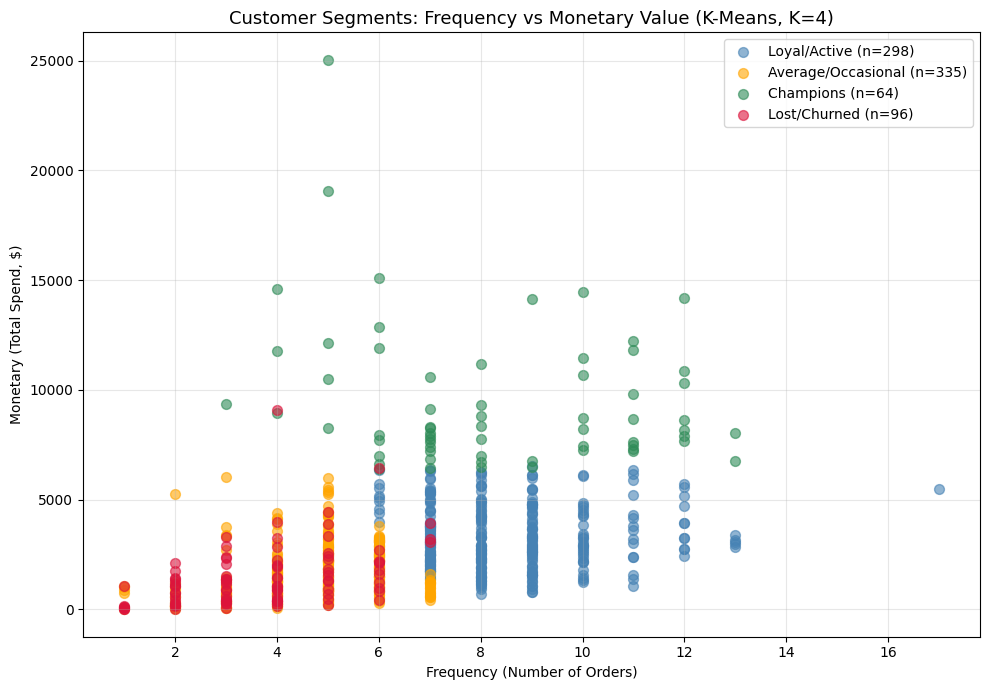

In [35]:
plt.figure(figsize=(10, 7))

colors = {0: 'steelblue', 1: 'orange', 2: 'seagreen', 3: 'crimson'}
labels = {0: 'Loyal/Active', 1: 'Average/Occasional', 2: 'Champions', 3: 'Lost/Churned'}

for cluster_id in sorted(rfm['Cluster'].unique()):
    subset = rfm[rfm['Cluster'] == cluster_id]
    plt.scatter(subset['Frequency'], subset['Monetary'],
                label=f"{labels[cluster_id]} (n={len(subset)})",
                color=colors[cluster_id], alpha=0.6, s=50)

plt.title('Customer Segments: Frequency vs Monetary Value (K-Means, K=4)', fontsize=13)
plt.xlabel('Frequency (Number of Orders)')
plt.ylabel('Monetary (Total Spend, $)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('customer_clusters.png', dpi=150)
plt.show()

In [36]:

test_w.to_csv('weekly_forecast_results.csv', index=False)


rfm['Segment_Label'] = rfm['Cluster'].map(labels)
rfm.to_csv('customer_segments.csv', index=False)


df.to_csv('superstore_cleaned.csv', index=False)


from google.colab import files
files.download('weekly_forecast_results.csv')
files.download('customer_segments.csv')
files.download('superstore_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
files.download('forecast_comparison.png')

files.download('elbow_method.png')
files.download('customer_clusters.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>